In [6]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np

## Using Scikit-learn ( Liner Regression )

#### 1. Import

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### 2. Read Dataframe and split it in input and output

In [8]:
df = pd.read_csv("50_Startups.csv")
x = df.drop(columns=['Profit'])
y=df.Profit

#### 3. Split Data in Training and Testing

In [9]:
x1 = pd.get_dummies(x, drop_first=True)

xTrain, xTest, yTrain, yTest = train_test_split(x1, y, test_size=0.2, random_state=42)

#### 4. Fit model

In [10]:
model = LinearRegression()

model.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.81, -0.07, 0.03,938.79, 6.99]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['R&D Spend','Administration','Marketing Spend','State_Florida', 'State_New York']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.403e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


#### 5. Predict test data

In [11]:
yPredict = model.predict(xTest)

#### 6. Plot Actual data and predicted data in scatter plot

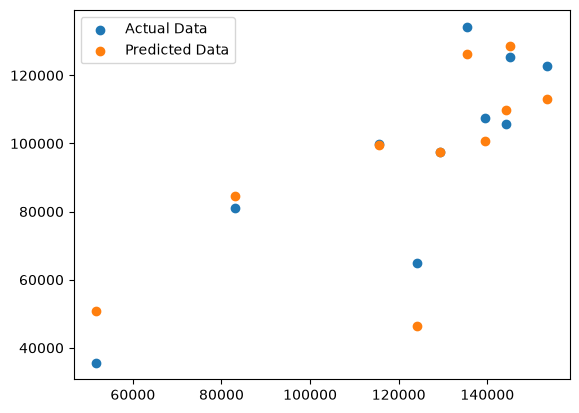

In [13]:
plt.scatter(xTest['Administration'], yTest, label="Actual Data")
plt.scatter(xTest['Administration'], yPredict,  label="Predicted Data")
plt.legend()

## Using Gradient Decent by Hand

#### 1. Spliting data in input and output

In [21]:
df = pd.read_csv("50_Startups.csv")
X = df['Marketing Spend'].values.astype(float)
X = (X - X.mean()) / X.std()
Y = df['Profit'].values.astype(float)
n = len(X)

#### 2. Defining Values and list

In [34]:
m, c = 0.0, 0.0 
lr = 0.001
epochs = 20000
loss_history = []
X

array([ 2.15394309e+00,  1.92360040e+00,  1.62652767e+00,  1.42221024e+00,
        1.28152771e+00,  1.25421046e+00, -6.88149930e-01,  9.32185978e-01,
        8.30886909e-01,  7.76107440e-01,  1.49807267e-01,  3.19833623e-01,
        3.20617441e-01,  3.43956788e-01,  3.75742273e-01,  4.19218702e-01,
        4.40446224e-01,  5.91016724e-01,  6.92992062e-01, -1.74312698e+00,
        7.23925995e-01,  7.32787791e-01,  7.62375876e-01,  7.74348908e-01,
       -5.81939297e-01, -6.03516725e-01, -6.35835495e-01,  1.17427116e+00,
       -7.67189437e-01, -8.58133663e-01, -9.90357166e-01, -1.01441945e+00,
       -1.36244978e+00,  2.98172434e-02, -1.87861793e-03, -4.54931587e-02,
       -8.17625734e-02, -1.15608256e-01, -2.12784866e-01, -2.97583276e-01,
       -3.15785883e-01, -3.84552407e-01, -5.20595959e-01, -1.44960468e+00,
       -1.50907418e+00, -1.72739998e+00,  7.11122474e-01, -1.74312698e+00,
       -1.74312698e+00, -1.36998473e+00])

#### 3. Define loss function, finding m & c, and Update rule

In [35]:
for i in range(epochs): 
    Y_pred = m * X + c                  # Formula of line 
    error  = Y_pred - Y                 # Calculating Error
 
    loss = (1/n) * np.sum(error ** 2)   # Loss fuction
    loss_history.append(loss)           # appending loss in loss_history
 
    dm = (2/n) * np.sum(error * X)      # Finding New slop m
    dc = (2/n) * np.sum(error)          # Finding New intercept c
 
    m = m - lr * dm                     # Update slop m
    c = c - lr * dc                     # Update intercept c
 
    if i % 4000 == 0:                   # Prints Value of m and c at each 4000 gap of i
        print(f'epoch {i}: loss={loss:.2f}  m={m:.3f}  c={c:.3f}') 

epoch 0: loss=14138927750.49  m=59.673  c=224.025
epoch 4000: loss=701871499.31  m=29826.753  c=111975.438
epoch 8000: loss=701870011.20  m=29836.659  c=112012.627
epoch 12000: loss=701870011.20  m=29836.662  c=112012.639
epoch 16000: loss=701870011.20  m=29836.662  c=112012.639


#### 4. Final Ans of slop m, and intercept c

In [36]:
print('Final parameters -> m:', m, ' c:', c)

Final parameters -> m: 29836.66199067488  c: 112012.63919999638


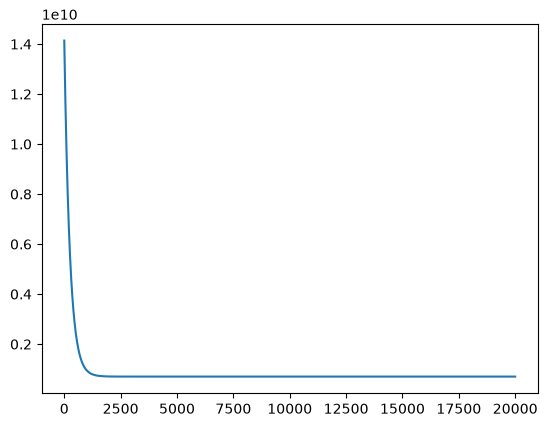

In [37]:
plt.plot(loss_history)